# Linear Differential Equations

## We aim to solve the following linear ODE:

$$y''' + y'' + y' + y = \cos(t)$$

We can rewrite this as a system of first-order ODEs by introducing new variables:
$$x_1 = y''$$
$$x_2 = y'$$
$$x_3 = y$$
Then we can express the system as:
$$x_1' = -x_3 - x_2 - x_1 + \cos(t)$$
$$x_2' = x_1$$
$$x_3' = x_2$$

The system can be represented in matrix form as:
$$\begin{bmatrix} x_1' \\ x_2' \\ x_3' \end{bmatrix} = \begin{bmatrix} -1 & -1 & -1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} + \begin{bmatrix} \cos(t) \\ 0 \\ 0 \end{bmatrix}$$

We can obtain a closed-form solution to this system:
$$X(t) = e^{At}X(0) + \int_{0}^{t} e^{A(t-s)}\,b(s)\,ds,$$
where
$$A = \begin{bmatrix} -1 & -1 & -1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}, \quad b(s)=\begin{bmatrix} \cos(s) \\ 0 \\ 0 \end{bmatrix}.$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

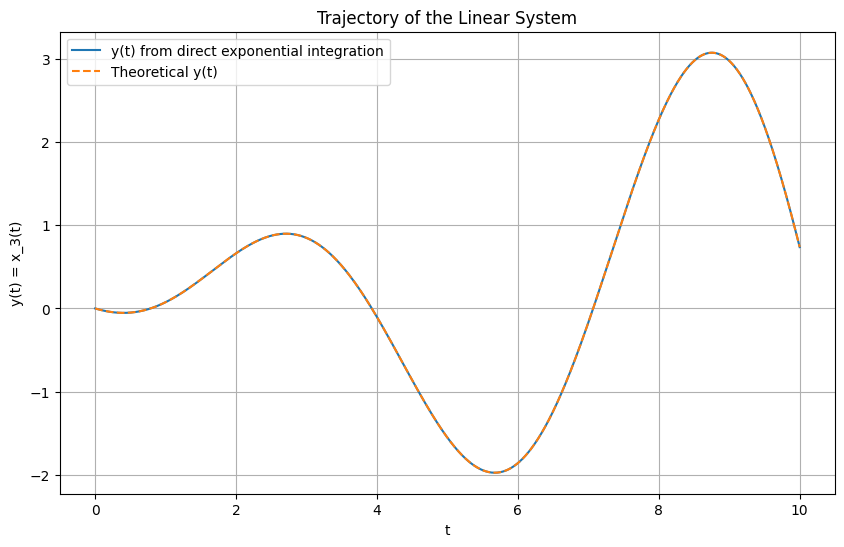

In [16]:
def forcing(t):
    return np.array([np.cos(t), 0.0, 0.0])

def trajectory_direct_exponential(T, x0, A, num_steps=1000):
    """
    Compute X(t) for X' = AX + b(t) using the variation-of-constants formula:
    X(t) = exp(A t) X(0) + ∫_0^t exp(A (t-s)) b(s) ds.
    """
    from scipy.integrate import quad_vec
    from scipy.linalg import expm

    t_grid = np.linspace(0.0, T, num_steps)
    traj = np.zeros((num_steps, len(x0)))

    for i, t in enumerate(t_grid):
        homogeneous = expm(A * t) @ x0

        def integrand(s):
            return expm(A * (t - s)) @ forcing(s)

        particular, _ = quad_vec(integrand, 0.0, t)
        traj[i] = homogeneous + particular

    return traj, t_grid


# Example usage
A = np.array([[-1, -1, -1], [1, 0, 0], [0, 1, 0]], dtype=float)
x0 = np.array([1/2, -1/4, 0], dtype=float)

traj, t = trajectory_direct_exponential(10, x0, A)
theoretical_trajectory = -1/4 * t * np.cos(t) + 1/4 * t * np.sin(t)


plt.figure(figsize=(10, 6))
plt.plot(t, traj[:, 2], label='y(t) from direct exponential integration')
plt.plot(t, theoretical_trajectory, label='Theoretical y(t)', linestyle='--')
plt.title('Trajectory of the Linear System')
plt.xlabel('t')
plt.ylabel('y(t) = x_3(t)')
plt.grid()
plt.legend()
plt.show()